# Employee Attrition Prediction — Sprint 1: Data Preprocessing
**Dataset:** Employee_Attrition.csv  
**Tech Stack:** Python | NumPy | Pandas | Matplotlib | Seaborn | Scikit-learn


---
## Step 1: Data Collection & Loading
- Import dataset from CSV
- Load using pandas
- Validate: Dataset size & Column structure


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [3]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("Employee_Attrition.csv")
df

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left


In [5]:
# Dataset Size
print("Shape:", df.shape)
print("Total Records:", df.shape[0])
print("Total Features:", df.shape[1])

Shape: (59598, 24)
Total Records: 59598
Total Features: 24


In [6]:
# Column Structure
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure',
       'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition'],
      dtype='object')

---
## Step 2: Initial Data Inspection
- `.head()`, `.tail()`, `.info()`, `.describe()`
- Check: Data types | Missing values | Unique values | Data consistency


In [7]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [8]:
df.tail()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left
59597,15796,56,Male,19,Technology,6660,Good,High,Average,0,...,3,Mid,Medium,81,No,No,No,Good,Low,Stayed


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [10]:
df.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,21519.150028,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,1.000000,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,18580.250000,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,37209.500000,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,55876.750000,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [11]:
# Check Missing Values
df.isna().sum()

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

In [12]:
# Missing Value Percentage
df.isna().sum() / len(df) * 100

Employee ID                 0.0
Age                         0.0
Gender                      0.0
Years at Company            0.0
Job Role                    0.0
Monthly Income              0.0
Work-Life Balance           0.0
Job Satisfaction            0.0
Performance Rating          0.0
Number of Promotions        0.0
Overtime                    0.0
Distance from Home          0.0
Education Level             0.0
Marital Status              0.0
Number of Dependents        0.0
Job Level                   0.0
Company Size                0.0
Company Tenure              0.0
Remote Work                 0.0
Leadership Opportunities    0.0
Innovation Opportunities    0.0
Company Reputation          0.0
Employee Recognition        0.0
Attrition                   0.0
dtype: float64

In [13]:
# Check for Duplicate Rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
# Check Unique Values — Categorical Columns
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    print(f"{col}: {df[col].unique()}")
    print()

Gender: ['Male' 'Female']

Job Role: ['Education' 'Media' 'Healthcare' 'Technology' 'Finance']

Work-Life Balance: ['Excellent' 'Poor' 'Good' 'Fair']

Job Satisfaction: ['Medium' 'High' 'Very High' 'Low']

Performance Rating: ['Average' 'Low' 'High' 'Below Average']

Overtime: ['No' 'Yes']

Education Level: ['Associate Degree' 'Master’s Degree' 'Bachelor’s Degree' 'High School'
 'PhD']

Marital Status: ['Married' 'Divorced' 'Single']

Job Level: ['Mid' 'Senior' 'Entry']

Company Size: ['Medium' 'Small' 'Large']

Remote Work: ['No' 'Yes']

Leadership Opportunities: ['No' 'Yes']

Innovation Opportunities: ['No' 'Yes']

Company Reputation: ['Excellent' 'Fair' 'Poor' 'Good']

Employee Recognition: ['Medium' 'Low' 'High' 'Very High']

Attrition: ['Stayed' 'Left']



### Observations
- **59,598 records** with **24 features**
- **No missing values** across any column
- **No duplicate rows** found
- Target column: `Attrition` → Binary ('Stayed' / 'Left')
- `Employee ID` is a unique identifier — should be dropped
- Mix of numerical and categorical features


---
## Step 3: Data Cleaning
- Handle missing values (None found)
- Remove duplicates (None found)
- Standardize column names
- Drop irrelevant columns


### Standardize Column Names

In [15]:
# Standardize: lowercase + replace spaces with underscores (matches Sprint-1 style)
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.columns

Index(['employee_id', 'age', 'gender', 'years_at_company', 'job_role',
       'monthly_income', 'work-life_balance', 'job_satisfaction',
       'performance_rating', 'number_of_promotions', 'overtime',
       'distance_from_home', 'education_level', 'marital_status',
       'number_of_dependents', 'job_level', 'company_size', 'company_tenure',
       'remote_work', 'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition'],
      dtype='object')

In [16]:
df.head()

,employee_id,age,gender,years_at_company,job_role,monthly_income,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,...,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


### Handle Missing Values

In [17]:
# Confirm — No missing values
df.isna().sum()

employee_id                 0
age                         0
gender                      0
years_at_company            0
job_role                    0
monthly_income              0
work-life_balance           0
job_satisfaction            0
performance_rating          0
number_of_promotions        0
overtime                    0
distance_from_home          0
education_level             0
marital_status              0
number_of_dependents        0
job_level                   0
company_size                0
company_tenure              0
remote_work                 0
leadership_opportunities    0
innovation_opportunities    0
company_reputation          0
employee_recognition        0
attrition                   0
dtype: int64

### Remove Duplicates

In [18]:
len(df)

59598

In [19]:
len(df[df.duplicated()])

0

### Drop Irrelevant Columns

In [20]:
# employee_id is a unique identifier — no predictive value for attrition
df.drop(columns=['employee_id'], inplace=True)
print("Columns after drop:", df.shape[1])

Columns after drop: 23


In [21]:
df.columns

Index(['age', 'gender', 'years_at_company', 'job_role', 'monthly_income',
       'work-life_balance', 'job_satisfaction', 'performance_rating',
       'number_of_promotions', 'overtime', 'distance_from_home',
       'education_level', 'marital_status', 'number_of_dependents',
       'job_level', 'company_size', 'company_tenure', 'remote_work',
       'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition'],
      dtype='object')

---
## Step 4: Exploratory Data Analysis (EDA)



In [22]:
# Define column groups
num_cols = [
    'age',
    'years_at_company',
    'monthly_income',
    'number_of_promotions',
    'distance_from_home',
    'number_of_dependents',
    'company_tenure'
]

cat_cols = [
    'gender',
    'job_role',
    'work-life_balance',
    'job_satisfaction',
    'performance_rating',
    'overtime',
    'education_level',
    'marital_status',
    'job_level',
    'company_size',
    'remote_work',
    'leadership_opportunities',
    'innovation_opportunities',
    'company_reputation',
    'employee_recognition'
]

target_col = 'attrition'

### Target Variable Distribution

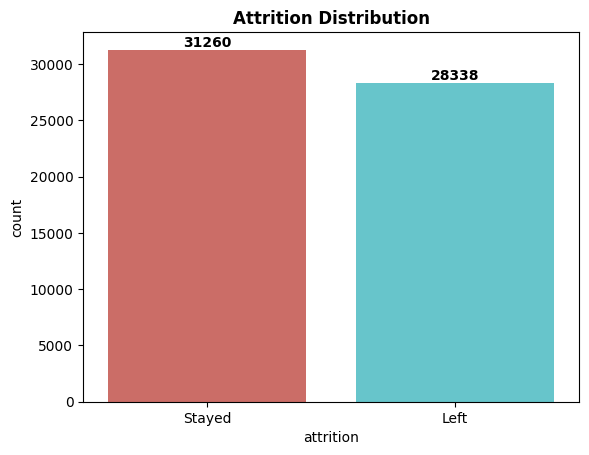

attrition
Stayed    31260
Left      28338
Name: count, dtype: int64

attrition
Stayed    52.451425
Left      47.548575
Name: proportion, dtype: float64


In [23]:
cp = sns.countplot(x=df[target_col], palette='hls')
plt.bar_label(cp.containers[0], fontweight='black')
plt.bar_label(cp.containers[1], fontweight='black')
plt.title('Attrition Distribution', fontweight='black')
plt.show()

print(df[target_col].value_counts())
print()
print(df[target_col].value_counts(normalize=True) * 100)

### Insights
- Dataset is **nearly balanced**: ~52.5% Stayed, ~47.5% Left
- No significant class imbalance — no resampling needed


### Univariate Analysis — Numerical Features

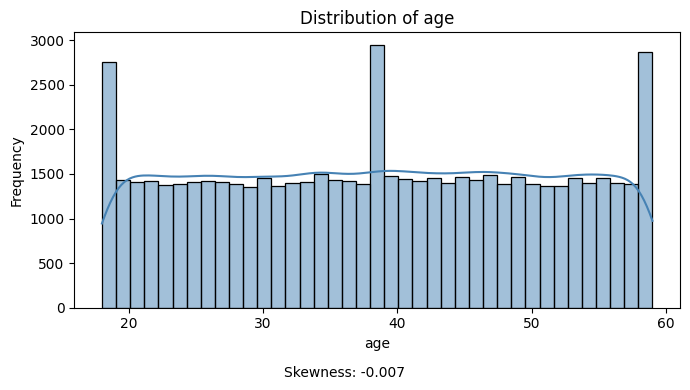

age → Skewness: -0.007
----------------------------------------


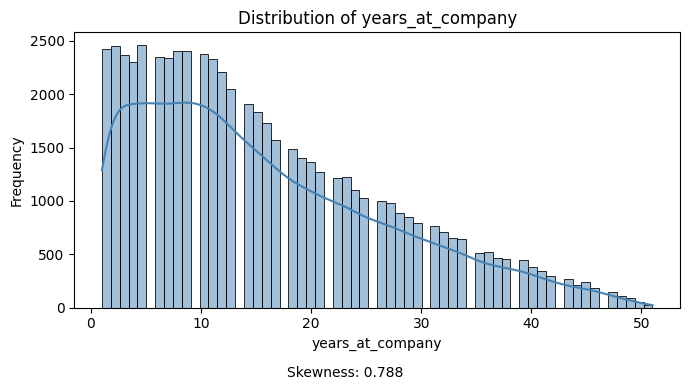

years_at_company → Skewness: 0.788
----------------------------------------


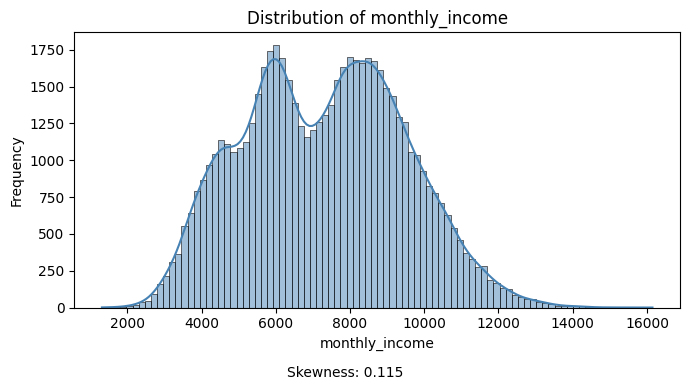

monthly_income → Skewness: 0.115
----------------------------------------


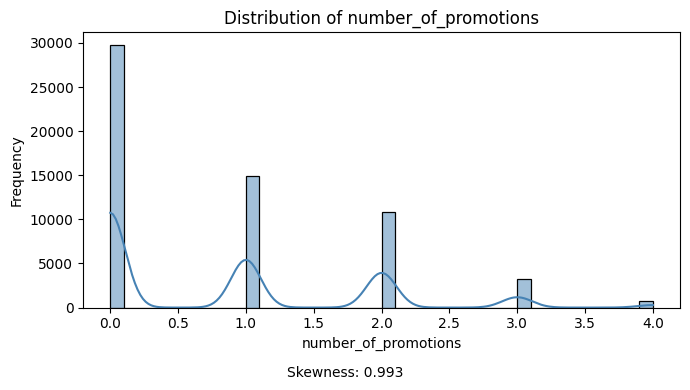

number_of_promotions → Skewness: 0.993
----------------------------------------


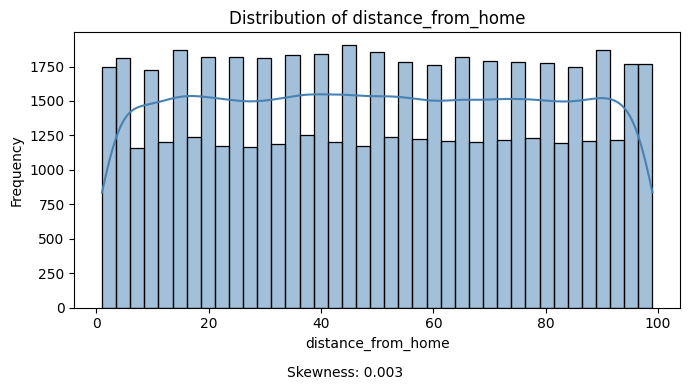

distance_from_home → Skewness: 0.003
----------------------------------------


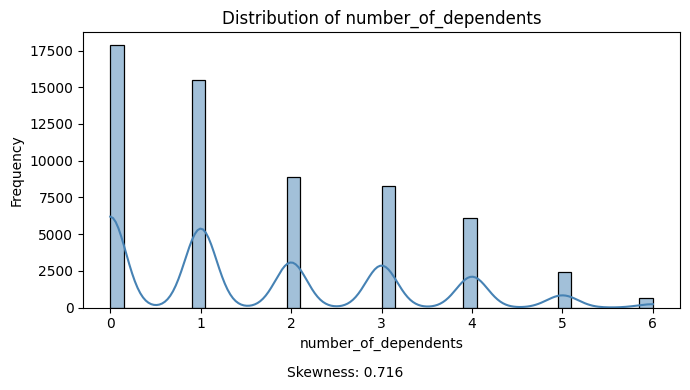

number_of_dependents → Skewness: 0.716
----------------------------------------


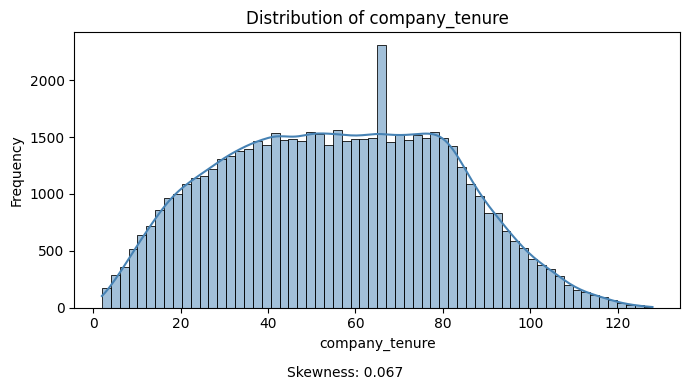

company_tenure → Skewness: 0.067
----------------------------------------


In [24]:
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    skewness = df[col].skew()
    plt.suptitle(f'Skewness: {skewness:.3f}', fontsize=10, y=0)
    plt.tight_layout()
    plt.show()
    print(f"{col} → Skewness: {skewness:.3f}")
    print("-" * 40)

### Insights
- **Age**: Nearly symmetric (skew ≈ 0) — no transformation needed
- **Years at Company**: Right-skewed (skew ≈ 0.79) — log transform recommended
- **Monthly Income**: Slightly right-skewed with outliers — capping recommended
- **Number of Promotions**: Right-skewed — genuine business data, no treatment
- **Distance from Home**: Nearly uniform distribution — no treatment
- **Number of Dependents**: Slight right skew — no treatment needed
- **Company Tenure**: Nearly symmetric — no transformation needed


### Univariate Analysis — Categorical Features

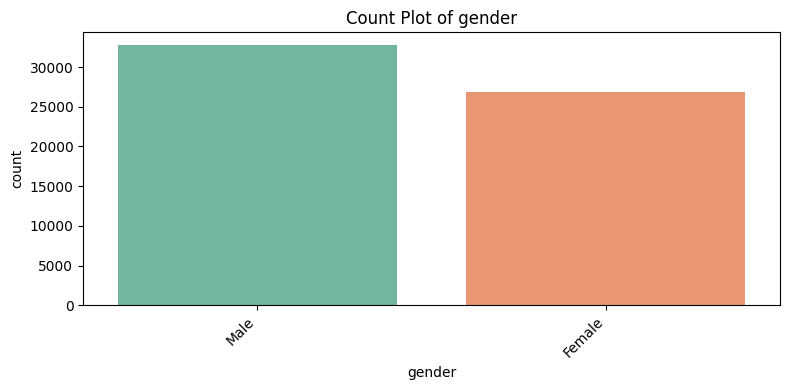

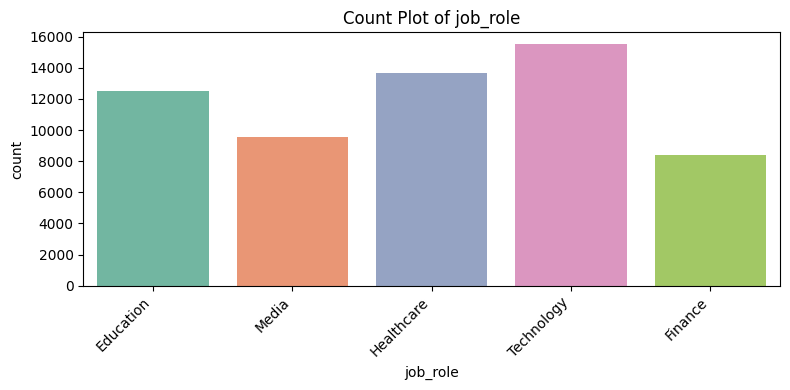

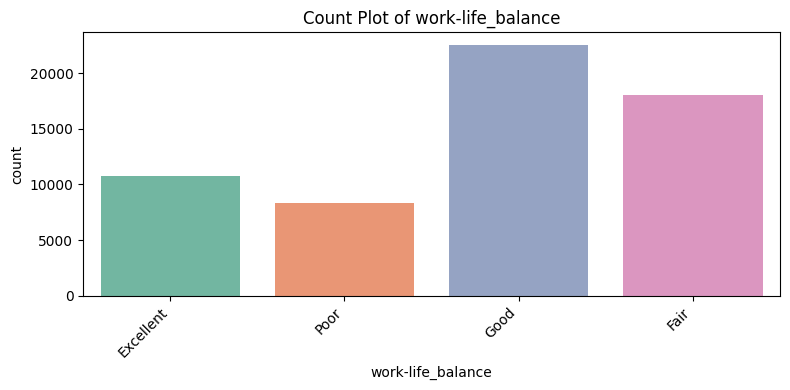

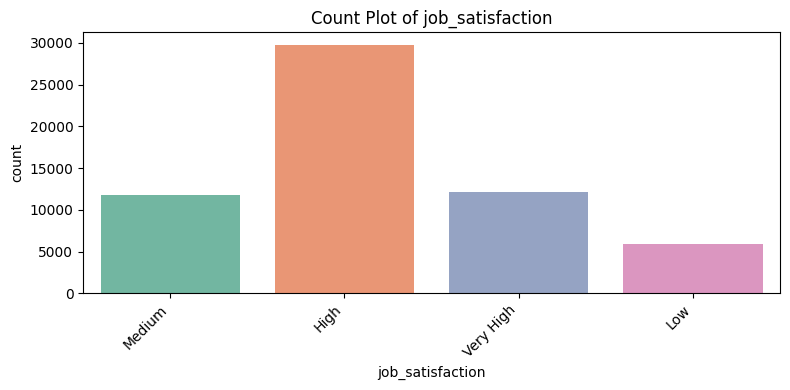

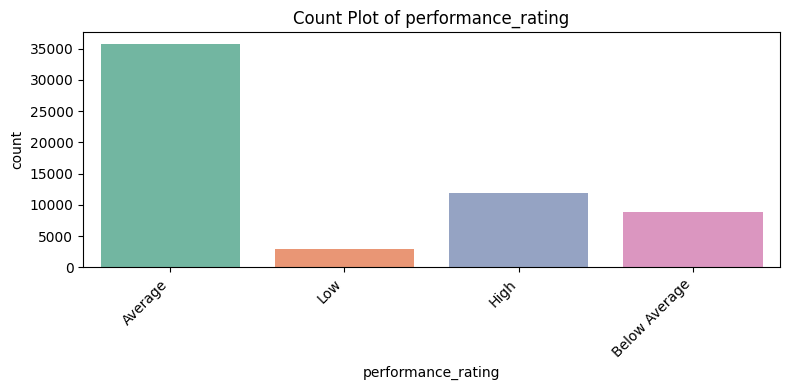

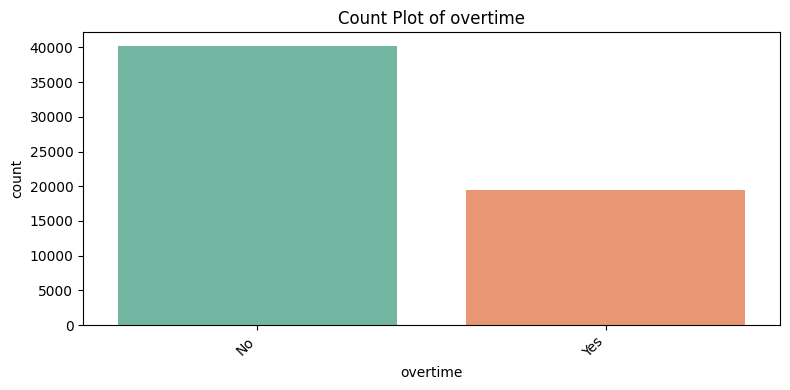

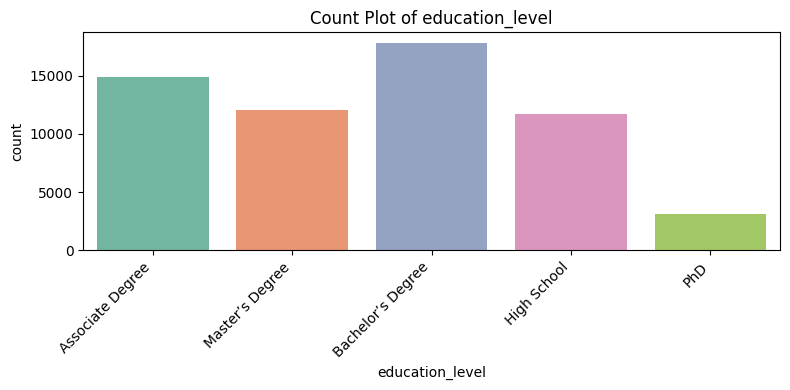

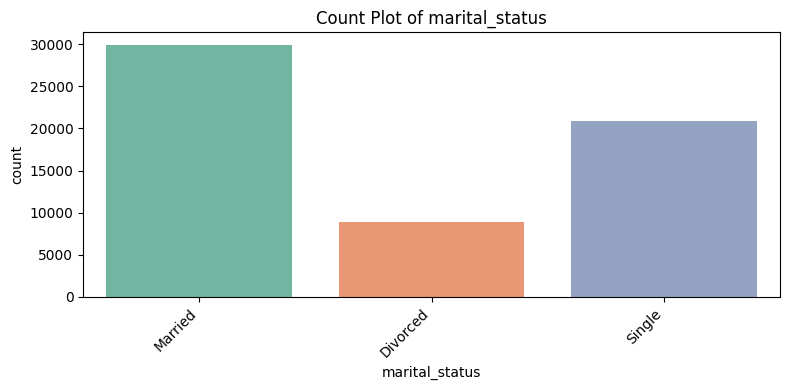

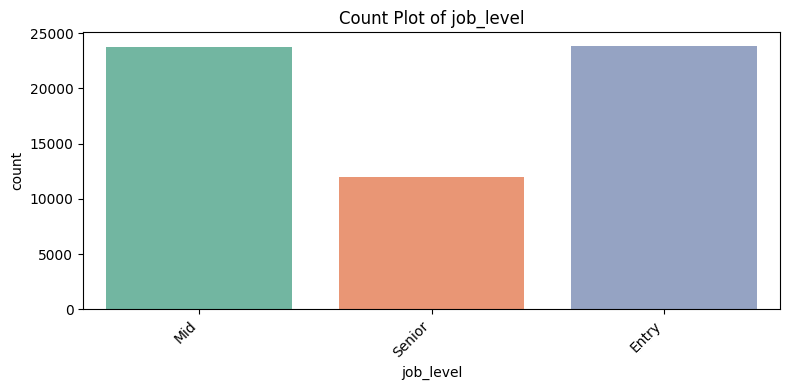

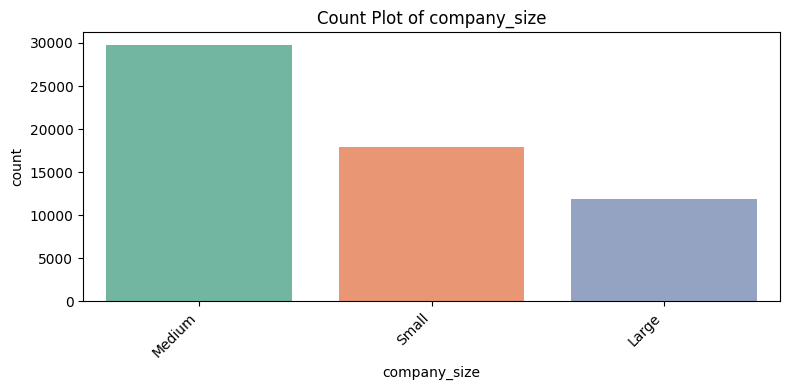

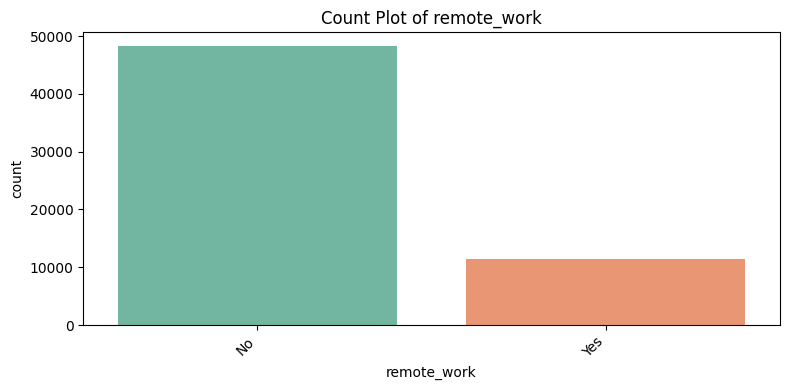

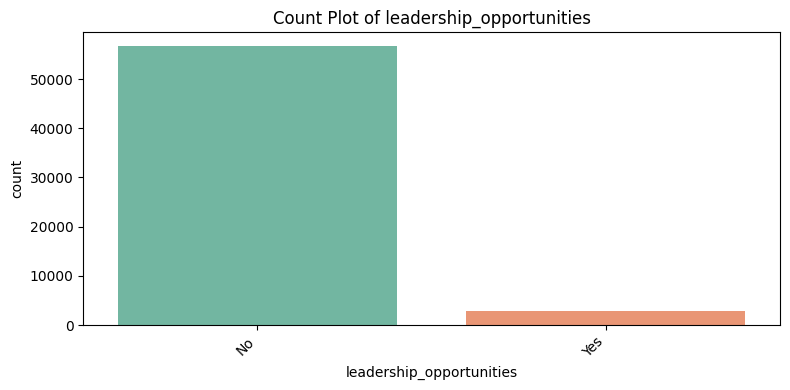

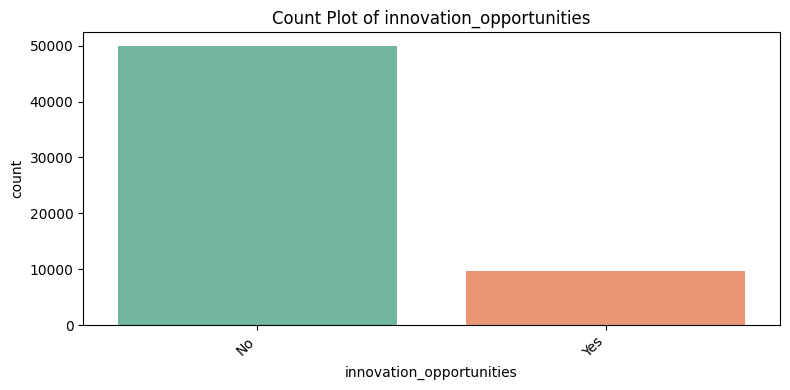

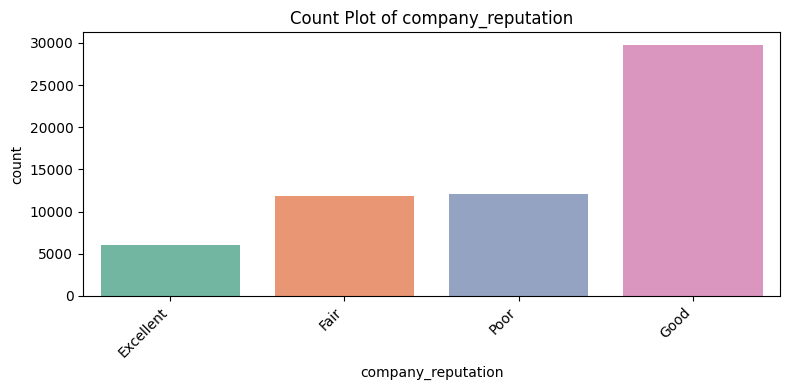

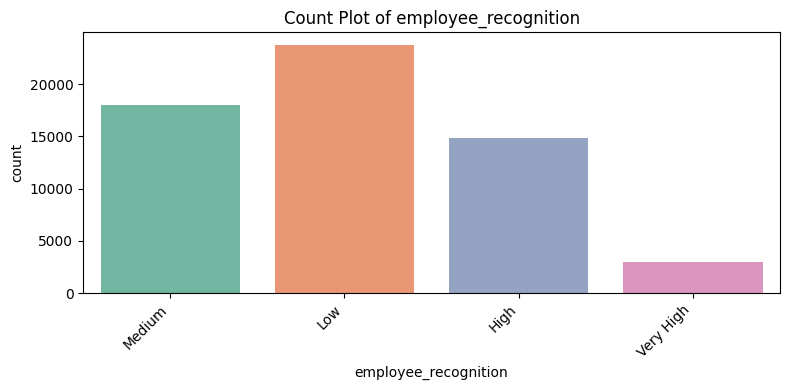

In [25]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col], palette='Set2')
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Bivariate Analysis — Numerical vs Target

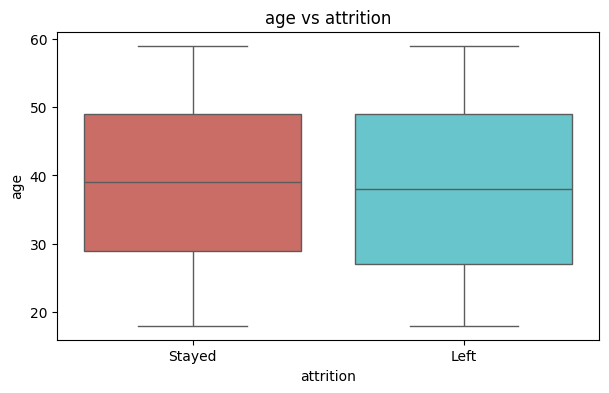

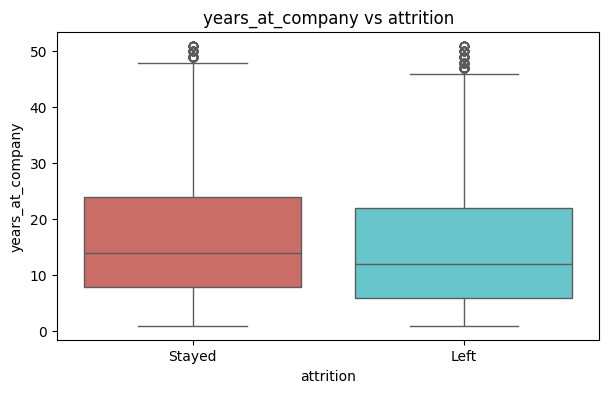

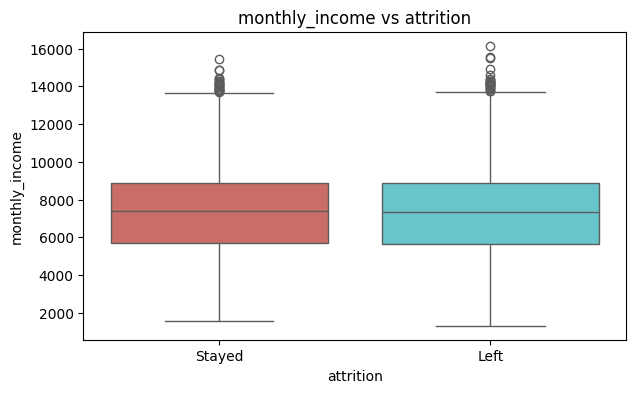

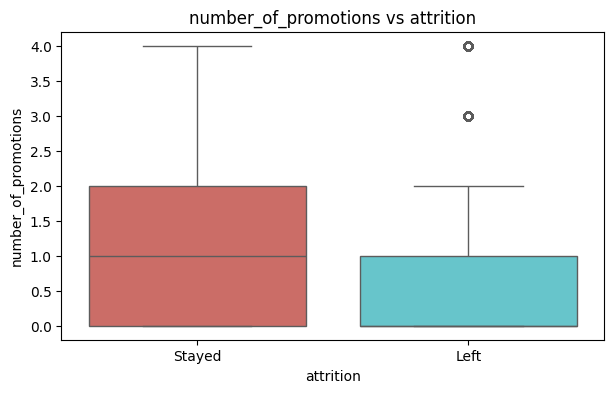

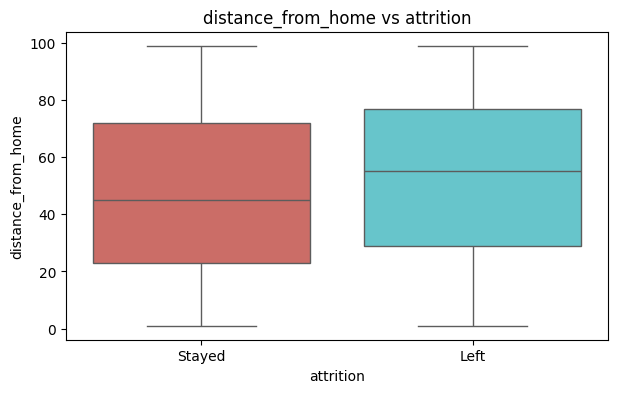

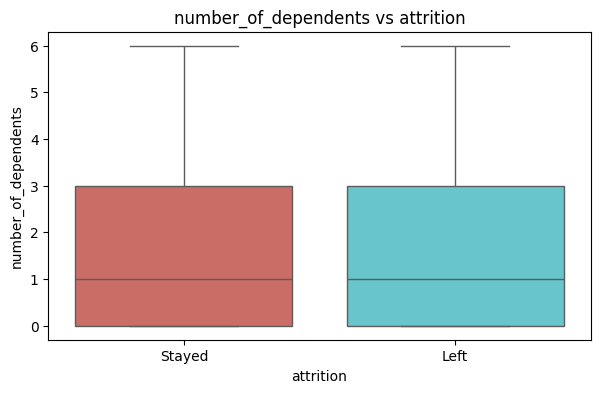

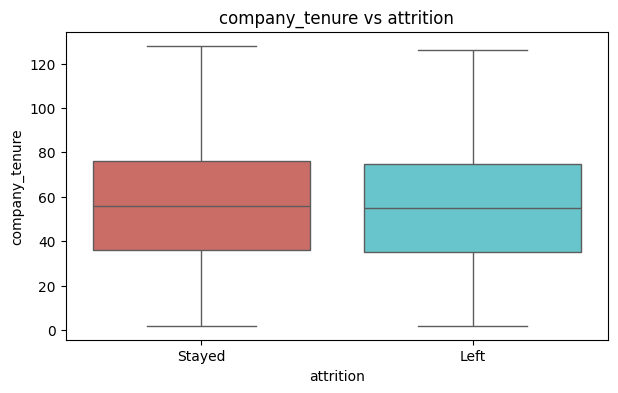

In [26]:
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[target_col], y=df[col], palette='hls')
    plt.title(f'{col} vs {target_col}')
    plt.show()

### Bivariate Analysis — Categorical vs Target

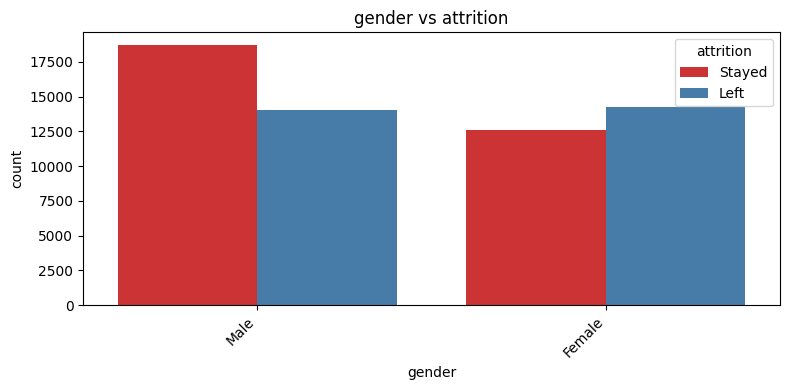

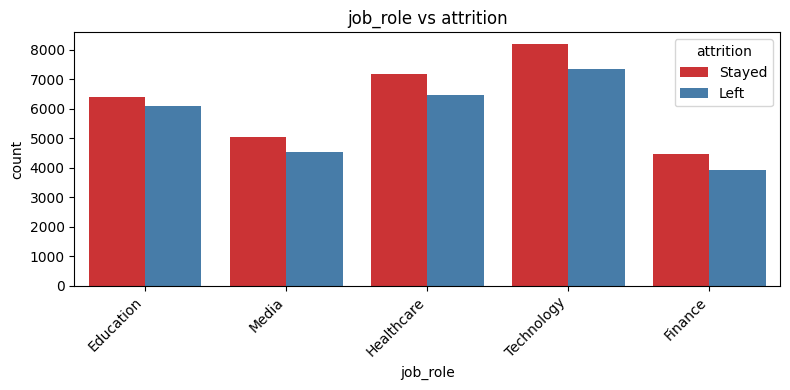

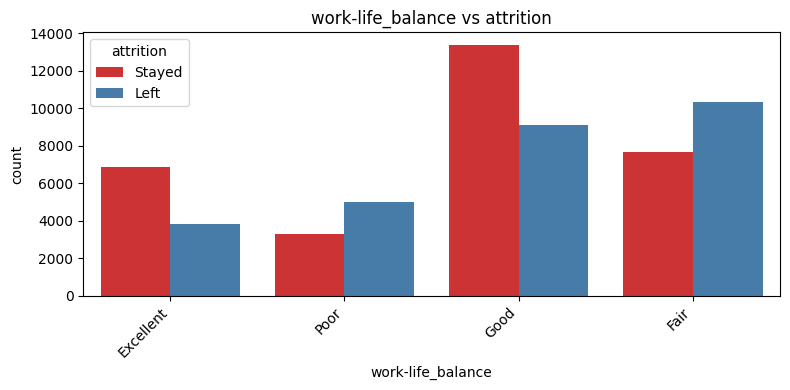

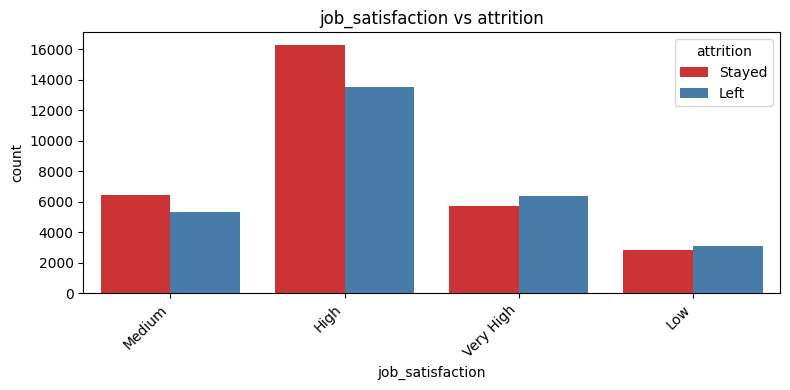

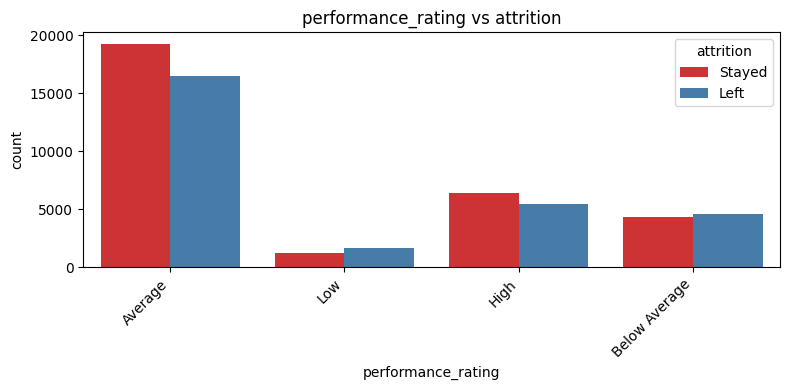

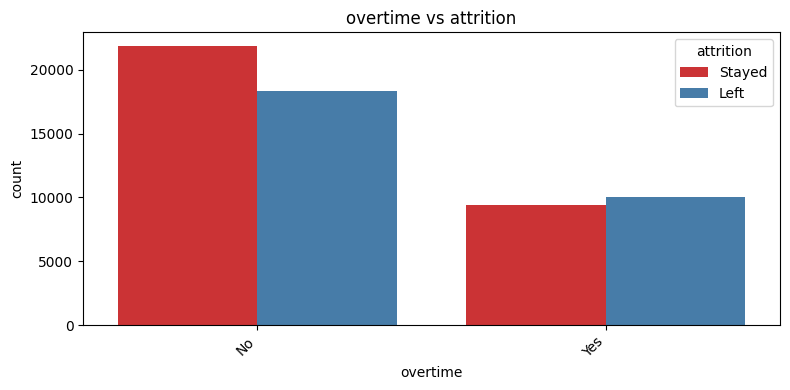

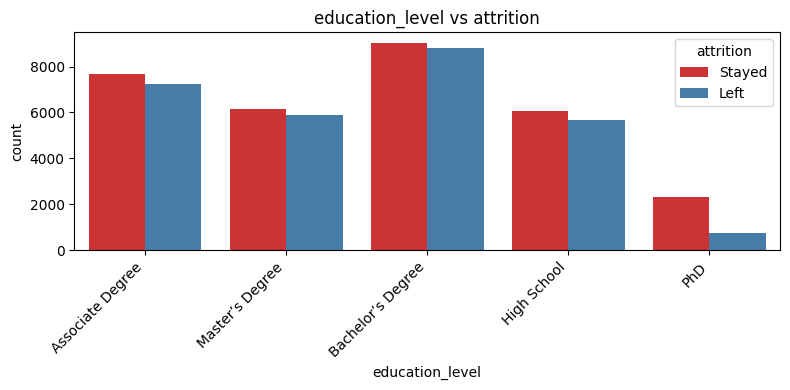

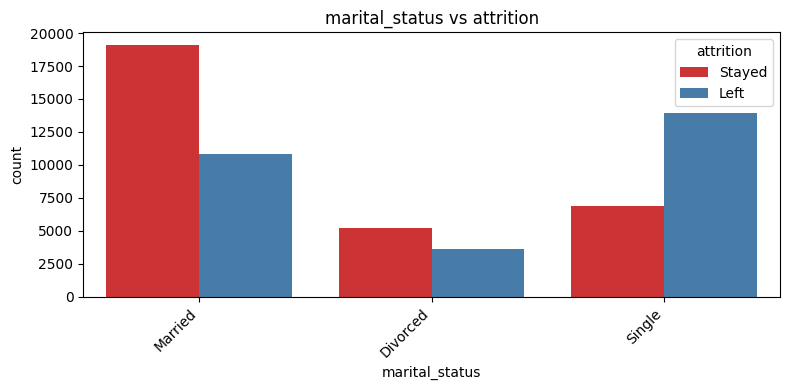

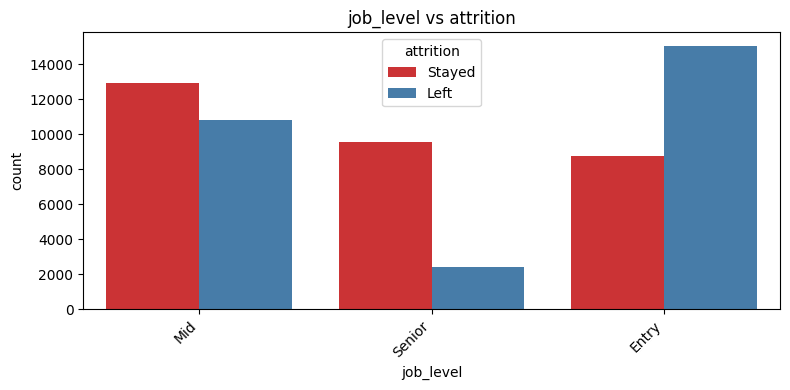

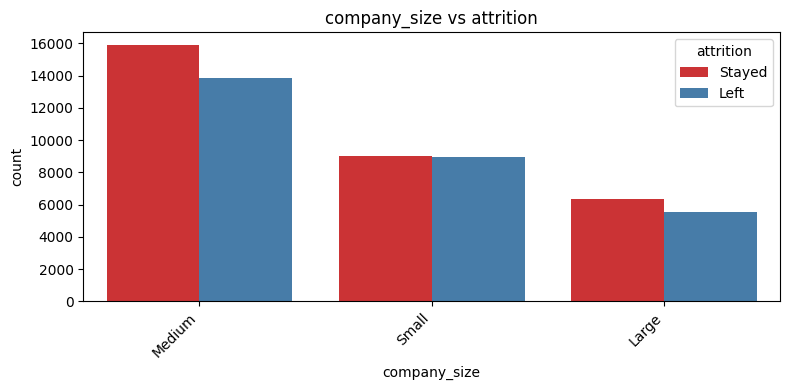

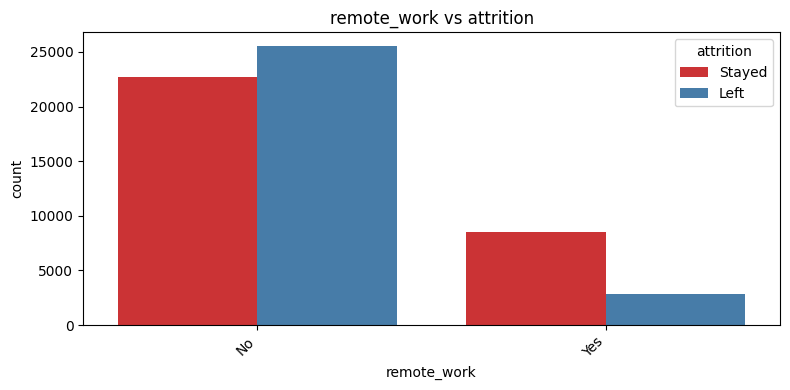

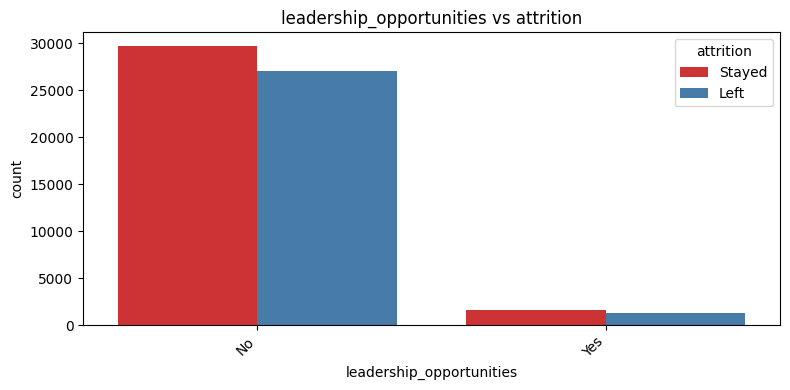

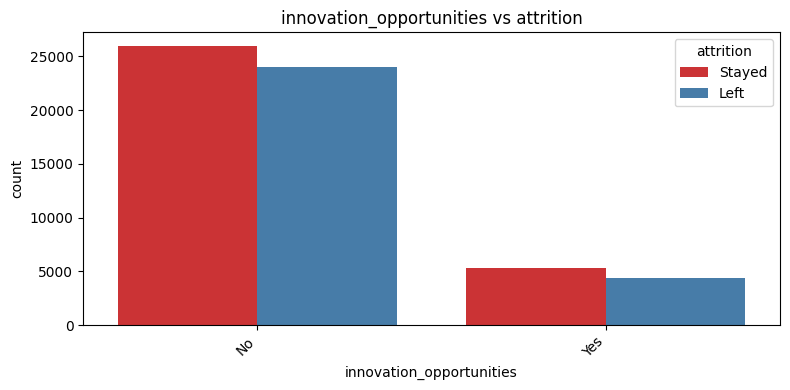

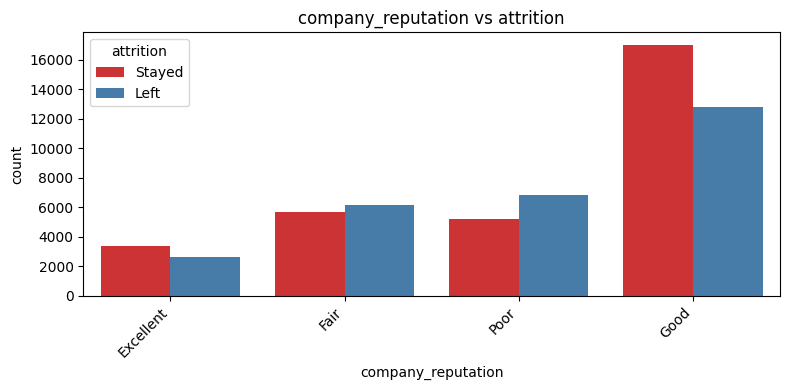

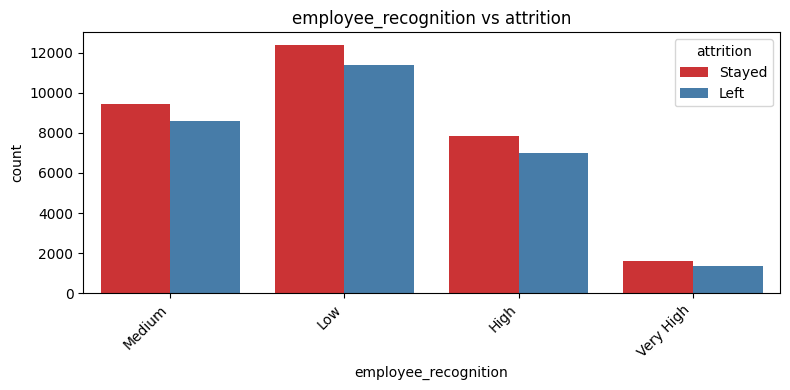

In [27]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(x=df[col], hue=df[target_col], palette='Set1')
    plt.title(f'{col} vs {target_col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Multivariate Analysis — Correlation Heatmap

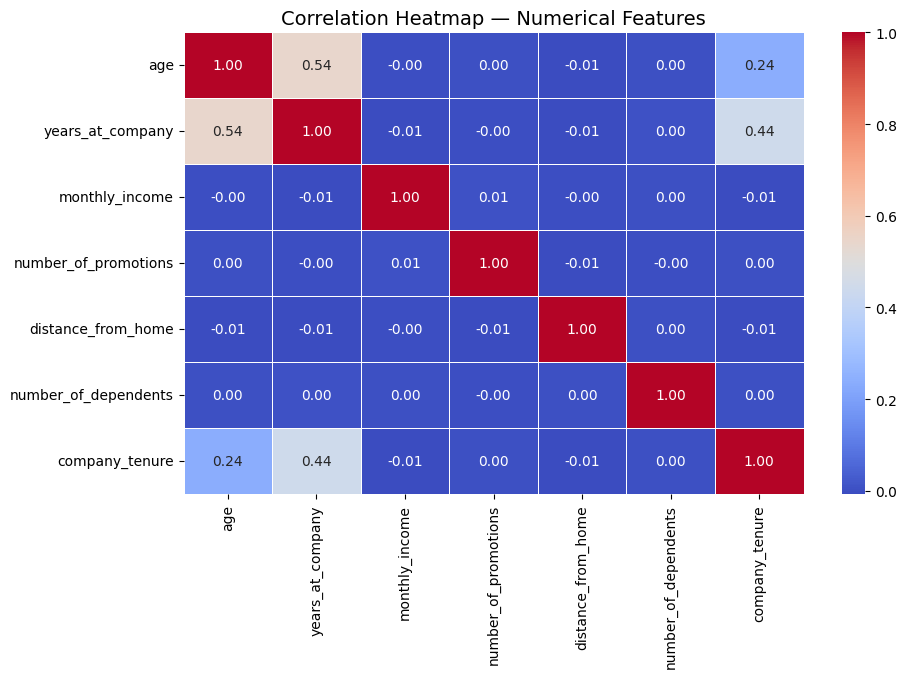

In [28]:
plt.figure(figsize=(10, 6))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14)
plt.show()

### Insights
- `years_at_company` and `company_tenure` show moderate positive correlation
- `monthly_income` has mild positive correlation with `age` and `years_at_company`
- No severe multicollinearity detected


### Multivariate Analysis — Pairplot

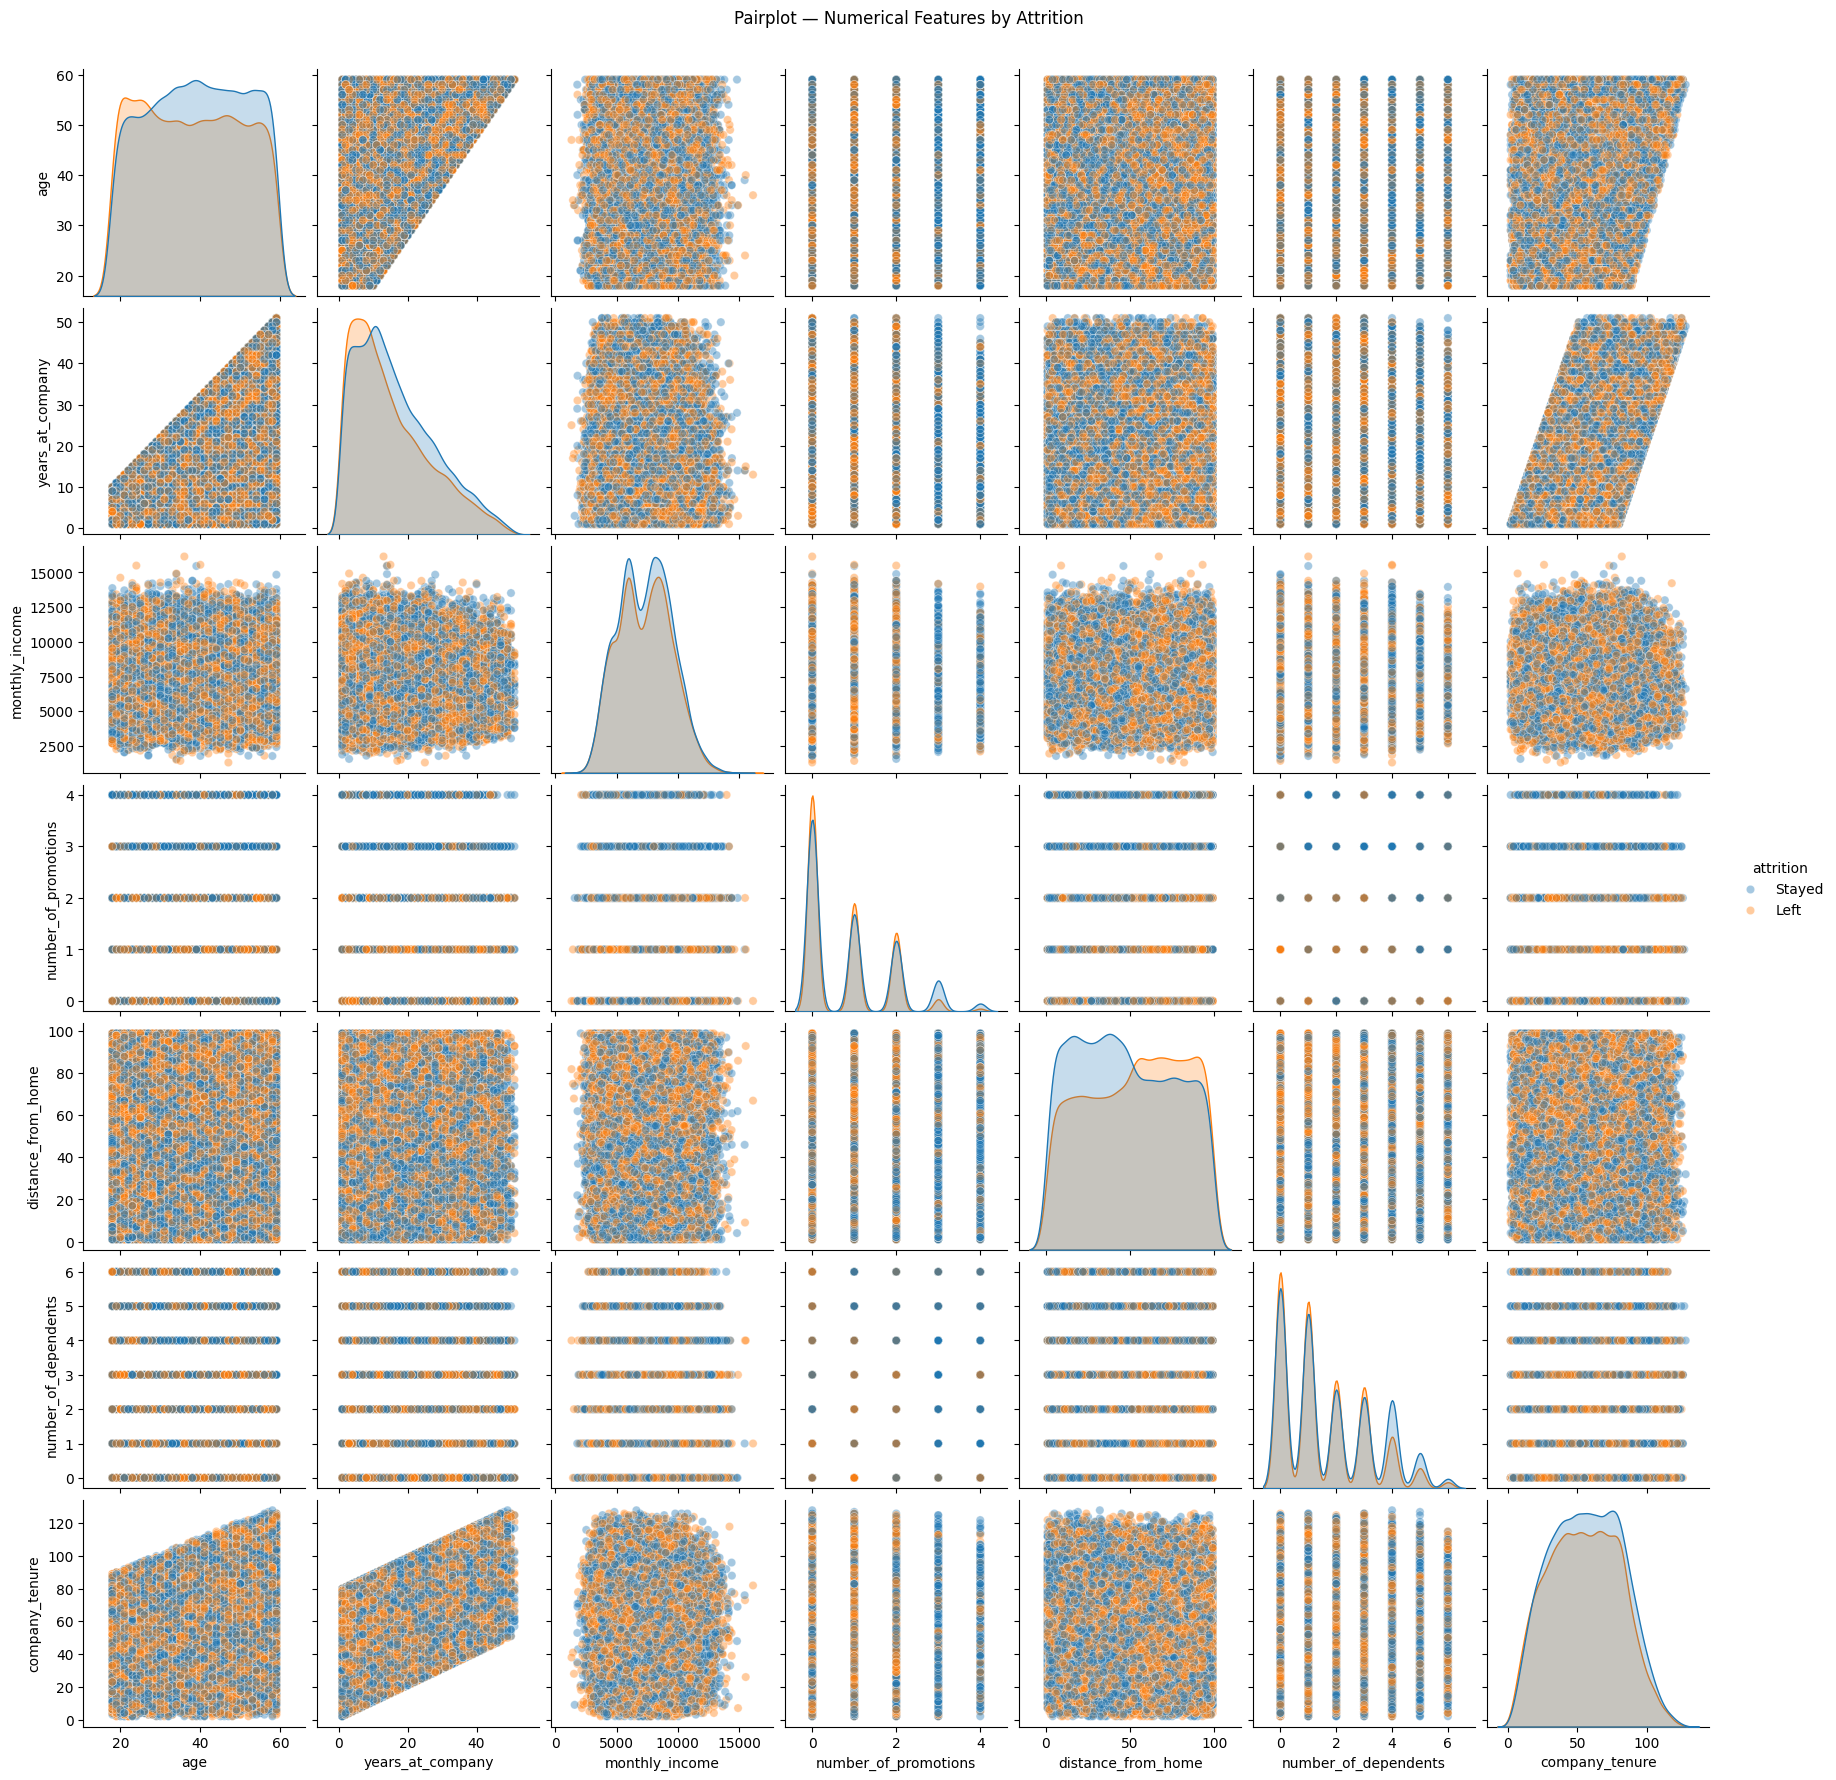

In [29]:
sns.pairplot(
    df[num_cols + [target_col]],
    hue=target_col,
    plot_kws={'alpha': 0.4}
)
plt.suptitle('Pairplot — Numerical Features by Attrition', y=1.02)
plt.show()

### Interaction Effects

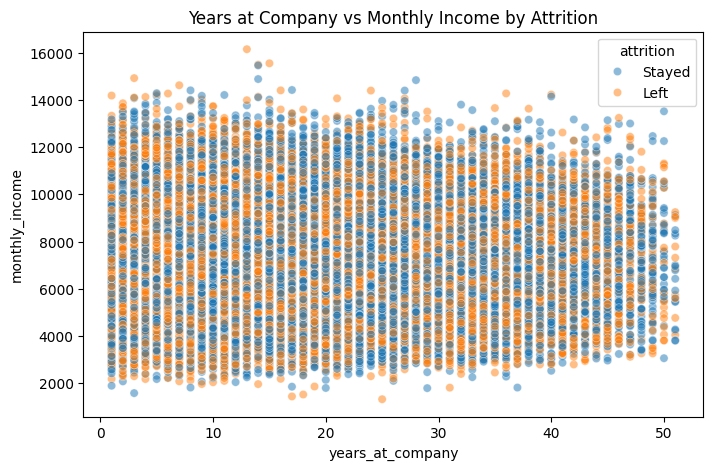

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='years_at_company', y='monthly_income', hue=target_col, data=df, alpha=0.5)
plt.title('Years at Company vs Monthly Income by Attrition')
plt.show()

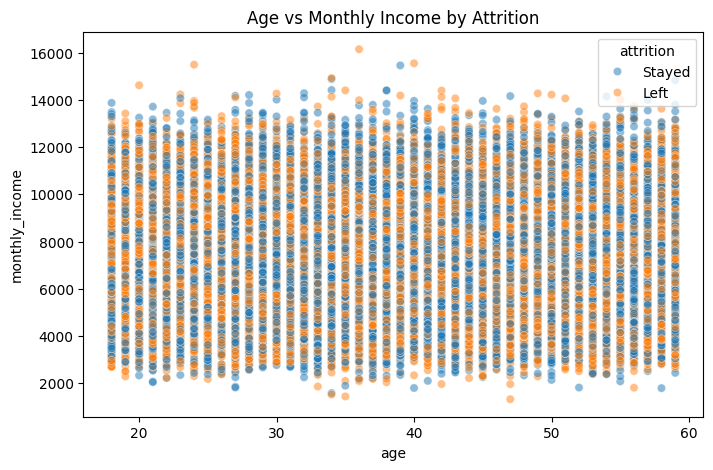

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='monthly_income', hue=target_col, data=df, alpha=0.5)
plt.title('Age vs Monthly Income by Attrition')
plt.show()

---
## Step 5: Outlier Detection & Treatment
- Visualize with **Boxplots**
- Detect using **IQR Method**
- Treatment: **Log Transform** (skewed) / **Capping** (upper extreme) / **No Treatment** (genuine business data)


In [32]:
# IQR Outlier Detection Function (from Reference)
def detect_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    print(f"{column} → Outliers: {outliers.shape[0]}  |  Lower: {lower:.2f}  |  Upper: {upper:.2f}")
    return lower, upper

### Age

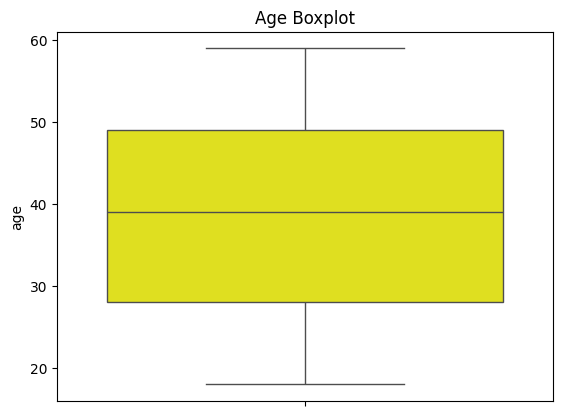

In [33]:
sns.boxplot(y=df['age'], color='yellow')
plt.title("Age Boxplot")
plt.show()

In [34]:
lower, upper = detect_outliers_iqr(df, 'age')

age → Outliers: 0  |  Lower: -3.50  |  Upper: 80.50


### Insights
- No outliers detected
- Age is uniformly distributed across 18–60 range — no treatment needed


### Years at Company

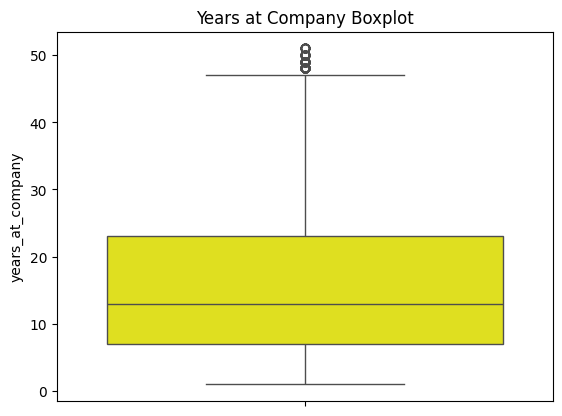

In [35]:
sns.boxplot(y=df['years_at_company'], color='yellow')
plt.title("Years at Company Boxplot")
plt.show()

In [36]:
lower, upper = detect_outliers_iqr(df, 'years_at_company')

years_at_company → Outliers: 273  |  Lower: -17.00  |  Upper: 47.00


### → Log Transformation (right-skewed, 273 outliers)

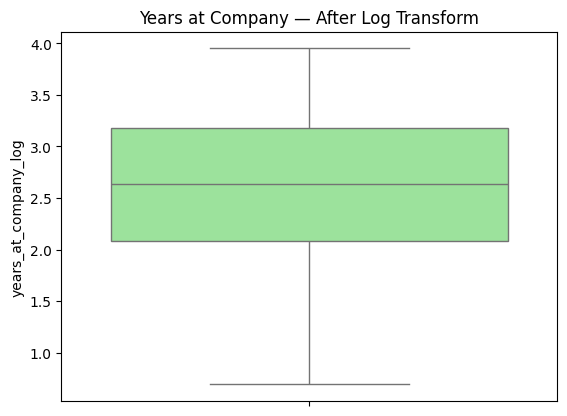

In [37]:
df['years_at_company_log'] = np.log1p(df['years_at_company'])

sns.boxplot(y=df['years_at_company_log'], color='lightgreen')
plt.title("Years at Company — After Log Transform")
plt.show()

In [38]:
# Drop original column — replaced by log-transformed version
df.drop('years_at_company', axis=1, inplace=True)
print("Column replaced: 'years_at_company' → 'years_at_company_log'")

Column replaced: 'years_at_company' → 'years_at_company_log'


### Monthly Income

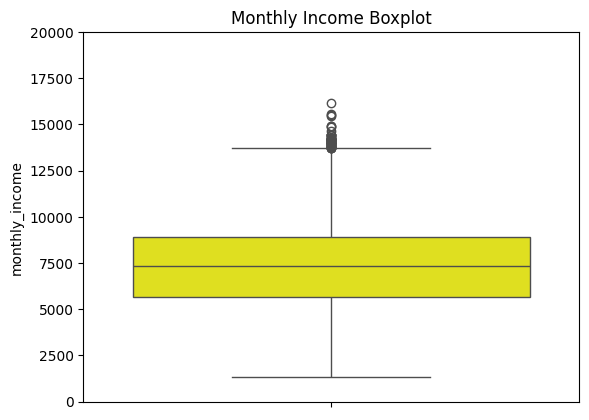

In [39]:
sns.boxplot(y=df['monthly_income'], color='yellow')
plt.title("Monthly Income Boxplot")
plt.ylim(0, 20000)
plt.show()

In [40]:
lower, upper = detect_outliers_iqr(df, 'monthly_income')

monthly_income → Outliers: 50  |  Lower: 825.00  |  Upper: 13713.00


### → Capping at Upper Bound (50 upper outliers detected)

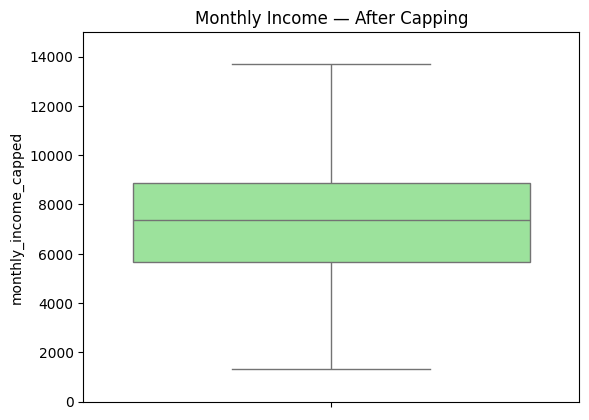

In [41]:
df['monthly_income_capped'] = np.where(
    df['monthly_income'] > upper,
    upper,
    df['monthly_income']
)

sns.boxplot(y=df['monthly_income_capped'], color='lightgreen')
plt.title("Monthly Income — After Capping")
plt.ylim(0, 15000)
plt.show()

In [42]:
# Drop original column — replaced by capped version
df.drop('monthly_income', axis=1, inplace=True)
print("Column replaced: 'monthly_income' → 'monthly_income_capped'")

Column replaced: 'monthly_income' → 'monthly_income_capped'


### Number of Promotions

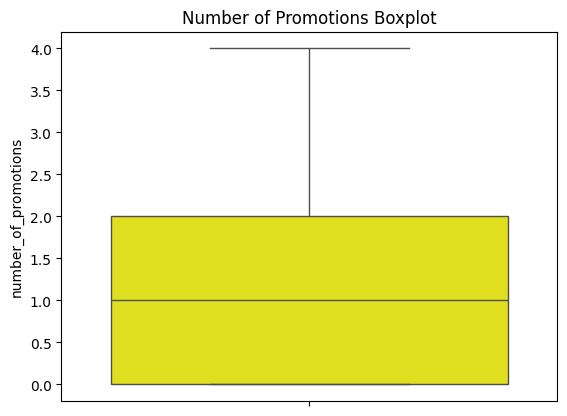

In [43]:
sns.boxplot(y=df['number_of_promotions'], color='yellow')
plt.title("Number of Promotions Boxplot")
plt.show()

In [44]:
lower, upper = detect_outliers_iqr(df, 'number_of_promotions')

number_of_promotions → Outliers: 0  |  Lower: -3.00  |  Upper: 5.00


### Insights — No Treatment Applied
- No statistical outliers detected
- High promotion counts reflect genuine employee growth


### Distance from Home

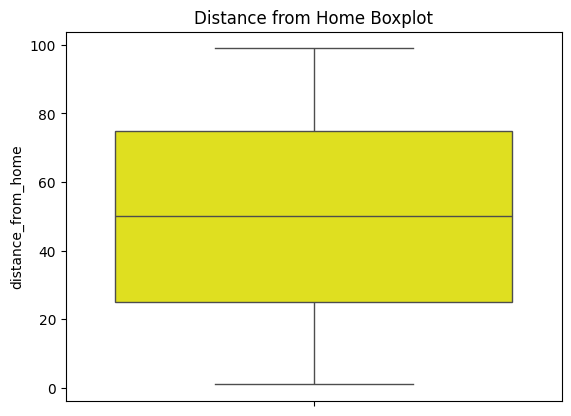

In [45]:
sns.boxplot(y=df['distance_from_home'], color='yellow')
plt.title("Distance from Home Boxplot")
plt.show()

In [46]:
lower, upper = detect_outliers_iqr(df, 'distance_from_home')

distance_from_home → Outliers: 0  |  Lower: -50.00  |  Upper: 150.00


### Insights — No Treatment Applied
- No outliers detected
- Long commute distances are valid real-world scenarios


### Number of Dependents

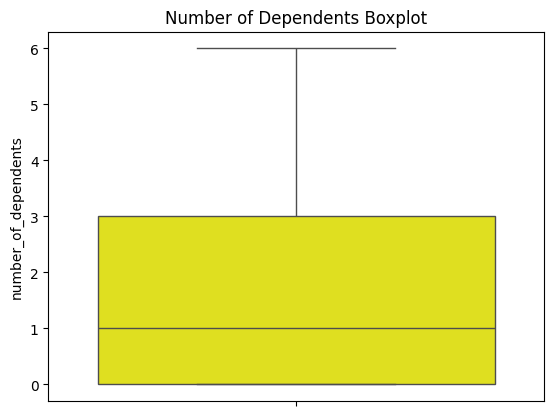

In [47]:
sns.boxplot(y=df['number_of_dependents'], color='yellow')
plt.title("Number of Dependents Boxplot")
plt.show()

In [48]:
lower, upper = detect_outliers_iqr(df, 'number_of_dependents')

number_of_dependents → Outliers: 0  |  Lower: -4.50  |  Upper: 7.50


### Insights — No Treatment Applied
- No outliers detected
- Varying family sizes are expected in real employee data


### Company Tenure

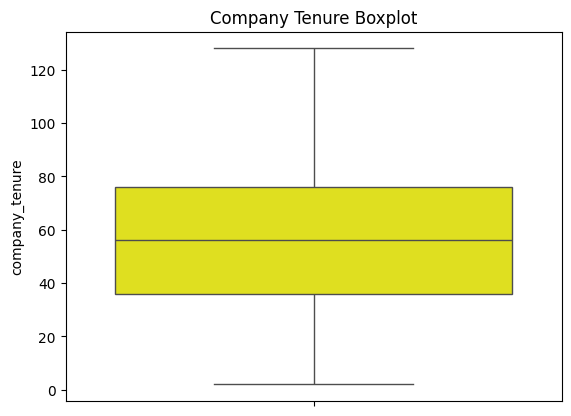

In [49]:
sns.boxplot(y=df['company_tenure'], color='yellow')
plt.title("Company Tenure Boxplot")
plt.show()

In [50]:
lower, upper = detect_outliers_iqr(df, 'company_tenure')

company_tenure → Outliers: 0  |  Lower: -24.00  |  Upper: 136.00


### Insights — No Treatment Applied
- No outliers detected
- Values reflect genuine experience levels


### Outlier Treatment Summary

| Column | Outliers | Treatment | Reason |
|---|---|---|---|
| age | 0 | None | Normally distributed |
| years_at_company | 273 | Log Transform | Right-skewed, extreme values |
| monthly_income | 50 | Capping (IQR Upper) | Salary extremes for senior roles |
| number_of_promotions | 0 | None | Genuine career growth data |
| distance_from_home | 0 | None | Valid travel distances |
| number_of_dependents | 0 | None | Normal family sizes |
| company_tenure | 0 | None | Valid experience levels |


---
## Step 6: Feature Encoding
- **Label Encoding** → Binary categorical columns (Yes/No, Male/Female)
- **One-Hot Encoding** → Multi-category columns


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       59598 non-null  int64  
 1   gender                    59598 non-null  object 
 2   job_role                  59598 non-null  object 
 3   work-life_balance         59598 non-null  object 
 4   job_satisfaction          59598 non-null  object 
 5   performance_rating        59598 non-null  object 
 6   number_of_promotions      59598 non-null  int64  
 7   overtime                  59598 non-null  object 
 8   distance_from_home        59598 non-null  int64  
 9   education_level           59598 non-null  object 
 10  marital_status            59598 non-null  object 
 11  number_of_dependents      59598 non-null  int64  
 12  job_level                 59598 non-null  object 
 13  company_size              59598 non-null  object 
 14  compan

In [52]:
df.head()

,age,gender,job_role,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,overtime,distance_from_home,education_level,...,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition,years_at_company_log,monthly_income_capped
0,31,Male,Education,Excellent,Medium,Average,2,No,22,Associate Degree,...,Medium,89,No,No,No,Excellent,Medium,Stayed,2.995732,5390.0
1,59,Female,Media,Poor,High,Low,3,No,21,Master’s Degree,...,Medium,21,No,No,No,Fair,Low,Stayed,1.609438,5534.0
2,24,Female,Healthcare,Good,High,Low,0,No,11,Bachelor’s Degree,...,Medium,74,No,No,No,Poor,Low,Stayed,2.397895,8159.0
3,36,Female,Education,Good,High,High,1,No,27,High School,...,Small,50,Yes,No,No,Good,Medium,Stayed,2.079442,3989.0
4,56,Male,Education,Fair,Very High,Average,0,Yes,71,High School,...,Medium,68,No,No,No,Fair,Medium,Stayed,3.737670,4821.0


### Label Encoding — Binary Categorical Columns

In [53]:
# Binary columns: Yes/No and Male/Female type
label_cols = [
    'gender',               # Male / Female
    'overtime',             # Yes / No
    'remote_work',          # Yes / No
    'leadership_opportunities',   # Yes / No
    'innovation_opportunities',   # Yes / No
    'attrition'             # Left / Stayed → Target
]

le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])
    print(f"{col} → Label Encoded")
    print(df[col].value_counts())
    print("-" * 40)

gender → Label Encoded
gender
1    32739
0    26859
Name: count, dtype: int64
----------------------------------------
overtime → Label Encoded
overtime
0    40148
1    19450
Name: count, dtype: int64
----------------------------------------
remote_work → Label Encoded
remote_work
0    48239
1    11359
Name: count, dtype: int64
----------------------------------------
leadership_opportunities → Label Encoded
leadership_opportunities
0    56680
1     2918
Name: count, dtype: int64
----------------------------------------
innovation_opportunities → Label Encoded
innovation_opportunities
0    49895
1     9703
Name: count, dtype: int64
----------------------------------------
attrition → Label Encoded
attrition
1    31260
0    28338
Name: count, dtype: int64
----------------------------------------


### One-Hot Encoding — Multi-Category Columns

In [54]:
# Multi-category columns → OHE with drop_first to avoid dummy variable trap
onehot_cols = [
    'job_role',
    'work-life_balance',
    'job_satisfaction',
    'performance_rating',
    'education_level',
    'marital_status',
    'job_level',
    'company_size',
    'company_reputation',
    'employee_recognition'
]

df_encoded = pd.get_dummies(
    df,
    columns=onehot_cols,
    drop_first=True
)

print("Encoding Completed!")
print("Encoded Dataset Shape:", df_encoded.shape)
print()
print("Columns after encoding:")
print(df_encoded.columns.tolist())

Encoding Completed!
Encoded Dataset Shape: (59598, 42)

Columns after encoding:
['age', 'gender', 'number_of_promotions', 'overtime', 'distance_from_home', 'number_of_dependents', 'company_tenure', 'remote_work', 'leadership_opportunities', 'innovation_opportunities', 'attrition', 'years_at_company_log', 'monthly_income_capped', 'job_role_Finance', 'job_role_Healthcare', 'job_role_Media', 'job_role_Technology', 'work-life_balance_Fair', 'work-life_balance_Good', 'work-life_balance_Poor', 'job_satisfaction_Low', 'job_satisfaction_Medium', 'job_satisfaction_Very High', 'performance_rating_Below Average', 'performance_rating_High', 'performance_rating_Low', 'education_level_Bachelor’s Degree', 'education_level_High School', 'education_level_Master’s Degree', 'education_level_PhD', 'marital_status_Married', 'marital_status_Single', 'job_level_Mid', 'job_level_Senior', 'company_size_Medium', 'company_size_Small', 'company_reputation_Fair', 'company_reputation_Good', 'company_reputation_Poor

In [55]:
df_encoded.head()

,age,gender,number_of_promotions,overtime,distance_from_home,number_of_dependents,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,...,job_level_Mid,job_level_Senior,company_size_Medium,company_size_Small,company_reputation_Fair,company_reputation_Good,company_reputation_Poor,employee_recognition_Low,employee_recognition_Medium,employee_recognition_Very High
0,31,1,2,0,22,0,89,0,0,0,...,True,False,True,False,False,False,False,False,True,False
1,59,0,3,0,21,3,21,0,0,0,...,True,False,True,False,True,False,False,True,False,False
2,24,0,0,0,11,3,74,0,0,0,...,True,False,True,False,False,False,True,True,False,False
3,36,0,1,0,27,2,50,1,0,0,...,True,False,False,True,False,True,False,False,True,False
4,56,1,0,1,71,0,68,0,0,0,...,False,True,True,False,True,False,False,False,True,False


---
## Step 7: Feature Scaling
- Apply **StandardScaler** on numerical features
- ⚠️ **Fit only on Training data** — Transform both train & test to avoid data leakage


In [56]:
# Updated numerical columns after transformation
scale_cols = [
    'age',
    'number_of_promotions',
    'distance_from_home',
    'number_of_dependents',
    'company_tenure',
    'years_at_company_log',
    'monthly_income_capped'
]

print("Columns to be scaled:")
print(scale_cols)

Columns to be scaled:
['age', 'number_of_promotions', 'distance_from_home', 'number_of_dependents', 'company_tenure', 'years_at_company_log', 'monthly_income_capped']


---
## Step 8: Train-Test Split
- Split: **80% Training | 20% Testing**
- `stratify=y` → Preserve class ratio in both splits
- `random_state=42` → Reproducibility


In [57]:
# Separate Features (X) and Target (y)
X = df_encoded.drop('attrition', axis=1)
y = df_encoded['attrition']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)
print()
print("Target Distribution:")
print(y.value_counts())

Feature Matrix Shape: (59598, 41)
Target Shape: (59598,)

Target Distribution:
attrition
1    31260
0    28338
Name: count, dtype: int64


In [58]:
# Train-Test Split — 80/20 Stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (47678, 41)
X_test : (11920, 41)
y_train: (47678,)
y_test : (11920,)


In [59]:
# Verify Stratification — Class ratio maintained
print("y_train Distribution:")
print(y_train.value_counts())
print()
print("y_test Distribution:")
print(y_test.value_counts())

y_train Distribution:
attrition
1    25008
0    22670
Name: count, dtype: int64

y_test Distribution:
attrition
1    6252
0    5668
Name: count, dtype: int64


### Apply Feature Scaling — Fit on Train, Transform Both

In [60]:
sc = StandardScaler()

# Fit ONLY on training data — prevent data leakage
X_train[scale_cols] = sc.fit_transform(X_train[scale_cols])

# Transform test data using train statistics
X_test[scale_cols] = sc.transform(X_test[scale_cols])

print("StandardScaler applied successfully!")
print()
print("X_train (after scaling) sample:")
X_train[scale_cols].head()

StandardScaler applied successfully!

X_train (after scaling) sample:


,age,number_of_promotions,distance_from_home,number_of_dependents,company_tenure,years_at_company_log,monthly_income_capped
1991,1.448690,-0.835031,0.491490,1.511588,0.520109,1.402257,-1.502683
1402,-0.953096,-0.835031,1.582184,-0.415335,-1.958857,-1.823045,-1.289186
39765,1.034589,2.182448,-0.247368,0.869280,1.818616,1.336060,1.232221
43544,0.454847,-0.835031,0.913694,2.153896,0.716853,1.113578,-1.047720
45355,-0.456175,0.170795,-1.126960,0.226973,0.244669,0.562493,-1.297111


In [61]:
print("X_test (after scaling) sample:")
X_test[scale_cols].head()

X_test (after scaling) sample:


,age,number_of_promotions,distance_from_home,number_of_dependents,company_tenure,years_at_company_log,monthly_income_capped
5033,0.868948,0.170795,-0.810307,-1.057643,-0.148818,1.301607,0.607113
6590,-0.870275,-0.835031,-1.197327,0.226973,-0.188167,0.200746,1.154840
27787,1.365869,-0.835031,-1.549164,-0.415335,1.346431,0.892403,0.164737
4151,1.117409,0.170795,-0.352919,-0.415335,-0.542305,-0.951446,1.496062
55589,0.454847,0.170795,-1.689899,0.869280,1.385780,0.113991,0.350264


---
## Preprocessing Summary

| Step | Action | Status |
|---|---|---|
| 1 | Data Loading & Validation | ✅ 59,598 rows × 24 cols |
| 2 | Initial Inspection | ✅ No missing values, correct dtypes |
| 3 | Data Cleaning | ✅ Dropped `employee_id`, standardized column names |
| 4 | EDA | ✅ Balanced target (~52.5% Stayed / ~47.5% Left) |
| 5 | Outlier Treatment | ✅ Log transform (`years_at_company`) + Cap (`monthly_income`) |
| 6 | Feature Encoding | ✅ Label Encoding (5 binary cols) + OHE (10 multi-cat cols) |
| 7 | Feature Scaling | ✅ StandardScaler (fit on train only) |
| 8 | Train-Test Split | ✅ 80/20 Stratified split |

**Final Dataset:**
- `X_train` shape: ~47,678 rows
- `X_test` shape:  ~11,920 rows
- Target: `attrition` (0 = Stayed, 1 = Left)


In [62]:
print("=" * 50)
print("Preprocessing Complete!")
print("=" * 50)
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print("=" * 50)

Preprocessing Complete!
X_train : (47678, 41)
X_test  : (11920, 41)
y_train : (47678,)
y_test  : (11920,)


In [83]:
df_encoded.to_csv("Employee_attrition_sprint1.csv")

# Sprint : 2
- ### Goal: Build baseline and compare multiple models

# Step 1: Baseline Model

In [63]:
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import ( classification_report,
accuracy_score,confusion_matrix,precision_score,f1_score,recall_score,roc_curve,roc_auc_score )

# Logistic Regression

In [81]:
lr = LogisticRegression()
lr.fit(X_train,y_train)
y_pred_test = lr.predict(X_test)
print("y_pred :", y_pred_test)
print()
Test_accuracy_score = accuracy_score(y_test,y_pred_test)
Train_accuracy_score = accuracy_score(y_train, y_pred_train)

print()
print("Test_accuracy_score:", accuracy_score(y_test,y_pred)) # accuracy score test data.

# Training accuracy
y_pred_train = lr.predict(X_train)
print("Train_accuracy_score:", accuracy_score(y_train, y_pred_train))
print("precision_score :", precision_score(y_train, y_pred_train))
print("recall_score :", recall_score(y_train, y_pred_train))
print("f1_score :", f1_score(y_train, y_pred_train))
print("roc_auc_score :", roc_auc_score(y_train, y_pred_train))

print()
print("Train_test_Difference :", Train_accuracy_score - Test_accuracy_score)

y_pred : [0 1 0 ... 0 0 0]



NameError: name 'y_pred_train' is not defined

In [ ]:
confusion_matrix(y_test,y_pred)

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot = True,fmt = 'd',xticklabels=['Stayed (0)', 'Left (1)'],
        yticklabels=['Stayed (0)', 'Left (1)'])

In [ ]:
print(classification_report(y_test,y_pred,target_names = ['Stayed(0)','Left(1)']))

# Train accuracy and Test accuracy is almost same
- data is Neither Overfitted nor Under_fitted

### Baseline Observations
- **Train Accuracy ≈ 75.1%** | **Test Accuracy ≈ 75.0%** → almost zero overfitting gap
- Logistic Regression generalises very well — a strong, stable baseline
- **F1 Score ≈ 76.3%** — this is our performance floor
- The model is slightly better at predicting "Left" than "Stayed" (check recall)
- Goal: tree-based and ensemble models should improve F1 above this floor

# Applying all models with by applying in functions.

========== LogisticRegression ==========
--- Training Metrics ---
Accuracy      : 0.7510
Precision     : 0.7618
Recall        : 0.7644
F1 Score      : 0.7631
ROC AUC Score : 0.7503

--- Testing Metrics ---
Accuracy      : 0.7498
Precision     : 0.7589
Recall        : 0.7665
F1 Score      : 0.7627
ROC AUC Score : 0.7490

--- Overfitting/Underfitting Check ---
Train-Test Diff: 0.0012



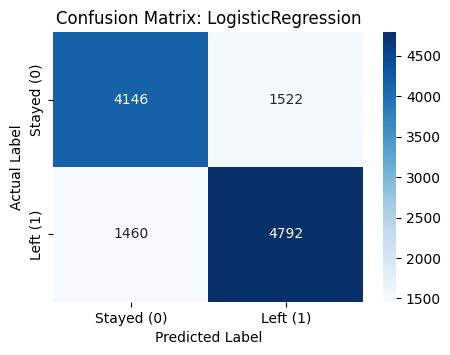

========== SVC ==========
--- Training Metrics ---
Accuracy      : 0.7979
Precision     : 0.8080
Recall        : 0.8062
F1 Score      : 0.8071
ROC AUC Score : 0.7974

--- Testing Metrics ---
Accuracy      : 0.7518
Precision     : 0.7629
Recall        : 0.7642
F1 Score      : 0.7636
ROC AUC Score : 0.7511

--- Overfitting/Underfitting Check ---
Train-Test Diff: 0.0461



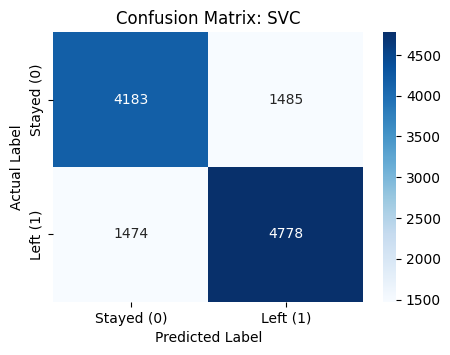

========== RandomForestClassifier ==========
--- Training Metrics ---
Accuracy      : 1.0000
Precision     : 1.0000
Recall        : 1.0000
F1 Score      : 1.0000
ROC AUC Score : 1.0000

--- Testing Metrics ---
Accuracy      : 0.7457
Precision     : 0.7583
Recall        : 0.7562
F1 Score      : 0.7573
ROC AUC Score : 0.7452

--- Overfitting/Underfitting Check ---
Train-Test Diff: 0.2543



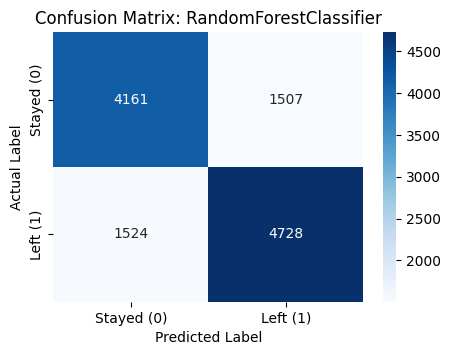

========== GaussianNB ==========
--- Training Metrics ---
Accuracy      : 0.7255
Precision     : 0.7610
Recall        : 0.6951
F1 Score      : 0.7265
ROC AUC Score : 0.7271

--- Testing Metrics ---
Accuracy      : 0.7242
Precision     : 0.7572
Recall        : 0.6982
F1 Score      : 0.7265
ROC AUC Score : 0.7256

--- Overfitting/Underfitting Check ---
Train-Test Diff: 0.0013



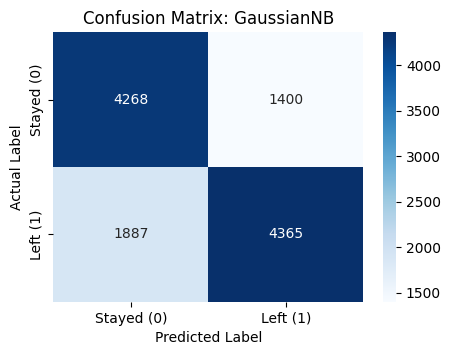

========== DecisionTreeClassifier ==========
--- Training Metrics ---
Accuracy      : 1.0000
Precision     : 1.0000
Recall        : 1.0000
F1 Score      : 1.0000
ROC AUC Score : 1.0000

--- Testing Metrics ---
Accuracy      : 0.6740
Precision     : 0.6893
Recall        : 0.6889
F1 Score      : 0.6891
ROC AUC Score : 0.6732

--- Overfitting/Underfitting Check ---
Train-Test Diff: 0.3260



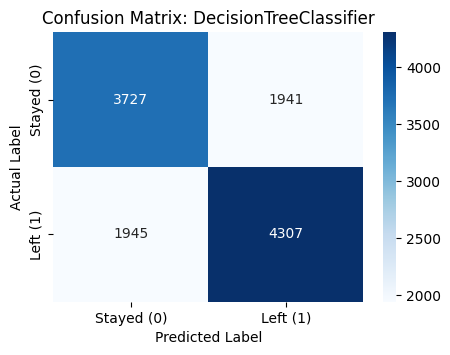

In [66]:

def evaluate_classifier(model, X_train, X_test, y_train, y_test):
    # 1. Train the model
    model.fit(X_train, y_train)
    
    # 2. Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # 3. Calculate Training Metrics
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_roc_auc = roc_auc_score(y_train, y_pred_train)
    
    # 4. Calculate Testing Metrics
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_roc_auc = roc_auc_score(y_test, y_pred_test)
    
    # 5. Print the Results dynamically
    print(f"========== {model.__class__.__name__} ==========")
    print("--- Training Metrics ---")
    print(f"Accuracy      : {train_accuracy:.4f}")
    print(f"Precision     : {train_precision:.4f}")
    print(f"Recall        : {train_recall:.4f}")
    print(f"F1 Score      : {train_f1:.4f}")
    print(f"ROC AUC Score : {train_roc_auc:.4f}\n")
    
    print("--- Testing Metrics ---")
    print(f"Accuracy      : {test_accuracy:.4f}")
    print(f"Precision     : {test_precision:.4f}")
    print(f"Recall        : {test_recall:.4f}")
    print(f"F1 Score      : {test_f1:.4f}")
    print(f"ROC AUC Score : {test_roc_auc:.4f}\n")
    
    print("--- Overfitting/Underfitting Check ---")
    print(f"Train-Test Diff: {train_accuracy - test_accuracy:.4f}")
    print("================================================\n")


def plot_confusion_matrix(model, X_test, y_test):
    # 1. Generate predictions
    y_pred = model.predict(X_test)
    
    # 2. Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # 3. Plot the heatmap
    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stayed (0)', 'Left (1)'],
                yticklabels=['Stayed (0)', 'Left (1)'])
    
    # 4. Add titles and labels
    plt.title(f"Confusion Matrix: {model.__class__.__name__}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()



# Initialize your dictionary of models
models = {
    "Logistic Regression": LogisticRegression(),
    "Support Vector Classifier": SVC(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier()
}



# Loop through and EXECUTE the functions
for name, model in models.items():
    # This trains the model and prints textual scores
    evaluate_classifier(model, X_train, X_test, y_train, y_test)
    
    # Since the model is now trained, this safely plots the matrix
    plot_confusion_matrix(model, X_test, y_test)

# Sprint 3

In [68]:
df.columns

Index(['age', 'gender', 'job_role', 'work-life_balance', 'job_satisfaction',
       'performance_rating', 'number_of_promotions', 'overtime',
       'distance_from_home', 'education_level', 'marital_status',
       'number_of_dependents', 'job_level', 'company_size', 'company_tenure',
       'remote_work', 'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition',
       'years_at_company_log', 'monthly_income_capped'],
      dtype='object')

In [71]:
df['career_growth_rate'] = df['number_of_promotions'] / (df['years_at_company_log'] + 1)

df['career_growth_rate'].head()

0    0.500534
1    1.149673
2    0.000000
3    0.324734
4    0.000000
Name: career_growth_rate, dtype: float64

In [74]:
df['income_per_tenure'] = df['monthly_income_capped'] / (df['years_at_company_log'] + 1)
df['income_per_tenure'].head()

0    1348.939226
1    2120.763239
2    2401.192310
3    1295.364743
4    1017.588897
Name: income_per_tenure, dtype: float64

In [77]:
df['loyalty_ratio'] = df['years_at_company_log'] / (df['age'] + 1)
df['loyalty_ratio'].head()

0    0.093617
1    0.026824
2    0.095916
3    0.056201
4    0.065573
Name: loyalty_ratio, dtype: float64

In [80]:
df['dependent_income'] = df['monthly_income_capped'] / (df['number_of_dependents'] + 1)
df['dependent_income'].head()

0    5390.000000
1    1383.500000
2    2039.750000
3    1329.666667
4    4821.000000
Name: dependent_income, dtype: float64